# Análisis exploratorio de la colección de proyectos

En este notebook, vamos a estudiar el corpus con la colección de proyectos que nos ha proporcionado la PAE (hemos filtrado usando keywords para reducir el número de proyectos)


In [2]:
# Necesario montar nuestra unidad de google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import os
import pandas as pd

os.chdir("/content/drive/MyDrive/PROYECTOS/PAE")
print("DIRECTORIO DE TRABAJO:", os.getcwd())
#os.listdir()

INPUT_FILE = "data/EUproject_aerospatial_filtered_5000.csv"
df = pd.read_csv(INPUT_FILE, encoding="utf-8")

print("Shape:", df.shape)
print("Columnas:", list(df.columns))

# borro la columna Nivel_1 que ya no nos aporta nada
df.drop(columns=["Nivel_1"], inplace=True)
print("Columnas:", list(df.columns))

df.head()


DIRECTORIO DE TRABAJO: /content/drive/MyDrive/PROYECTOS/PAE
Shape: (5374, 4)
Columnas: ['title', 'description', 'Nivel_1', 'text']
Columnas: ['title', 'description', 'text']


,title,description,text
0,Tilt Rotor ATM Integrated Validation of Enviro...,"""Cleansky-Green Rotor Craft sub-project 5 is a...",Tilt Rotor ATM Integrated Validation of Enviro...
1,Prefabricated CFRP Parts,Due to the increasing use of carbon fibre rein...,Prefabricated CFRP Parts. Due to the increasin...
2,Smart Electrical Power Distribution Centre,"The SEPDC project will conceive, design and ma...",Smart Electrical Power Distribution Centre. Th...
3,GNSS-based ATM for Rotorcraft to Decrease Emis...,The GARDEN project - GNSS-based ATM for Rotorc...,GNSS-based ATM for Rotorcraft to Decrease Emis...
4,Curved Applications for Rotorcraft Environment...,"""The CARE project – Curved Applications for Ro...",Curved Applications for Rotorcraft Environment...


Podemos comprobar que todos los proyectos tienen texto asociado.:



In [9]:
df[["title", "description", "text"]].isnull().mean()


,0
title,0.0
description,0.0
text,0.0


## Longitud de los textos

In [13]:
for col in ["title", "description", "text"]:
    #df[f"{col}_n_chars"] = df[col].astype(str).str.len()
    df[f"{col}_n_words"] = df[col].astype(str).str.split().apply(len)

df[[c for c in df.columns if "n_words" in c]].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95]
)

,title_n_words,description_n_words,text_n_words
count,5374.000000,5374.000000,5374.000000
mean,9.806290,264.220134,274.026424
std,4.695677,49.275651,49.778501
min,1.000000,19.000000,23.000000
25%,6.000000,254.000000,263.000000
50%,9.000000,277.000000,287.000000
75%,12.000000,292.000000,302.000000
95%,19.000000,311.000000,323.000000
max,42.000000,615.000000,621.000000


## ¿Cómo son los títulos?

Los títulos son cortos y bastante homogéneos. 50% tienen entre 6 y 12 palabras. No hay dispersión extrema. Hay algunos títulos muy largos (42 palabras) → revisar por posible “mini-abstract”.

El title siempre va a concentrar mucha información de núcleo porque los títulos de un proyecto suelen nombrar el problema a resolver, suelen mencionar la tecnología clave, nombra el dominio de aplicación, y también suele incluir términos específicos.
Sin embargo, los títulos son demasiado cortos como para poder utilizarlos en una clasificación con una taxonomía tan compleja como la que estabamos trabajando.


Miramos qué proyectos tienen más de X tokens en sus títulos. Probamos con distintos valores de X (X>19). El único titulo que parece un párrafo es el del proyecto que comienza con "SmartAgriFood2 is a a phase 3 FI-PPP project..."


In [30]:
X = 42
df_long_titles = df[df["title_n_words"] >= X].copy()

print(f"Número de titles con más de {X} palabras: {len(df_long_titles)}")
df_long_titles[["title", "title_n_words"]].head()
for title in df_long_titles["title"]:
    print(title)
    print("-" * 80)

Número de titles con más de 42 palabras: 1
SmartAgriFood2 is a a phase 3 FI-PPP project supporting SMEs in the development of smart services and applications for the agri-food sector based on the validation and use of results from the SmartAgriFood (Phase 1) and FI-Space (Phase 2) FI PPP projects
--------------------------------------------------------------------------------


## ¿Cómo son las descripciones de los proyectos??

Las descripciones de los proyectos son textos largos y relativamente homogéneos. Su IQR (25%–75%) es muy concentrado (254–292 proyectos).

También podemos ver que su desviación estándar (~49) es baja comparada con la media (264.2). Esto indica que estamos frente a una estructura muy estable de la descripción de los proyectos, que puede sugerir que probablemente hay un formato institucional estándar para su descripción, es decir, una posible plantilla.


## ¿Cómo son los textos completos (title + description)??
Como era de esperar, su media es 274 palabras, y su distribución es casi idéntica a la que hemos observado en el campo description (el título añade pocos términos).

Los textos son muy homogeneos, su IQR está muy concentrado entre 263 y 302 palabras.
El 95% de los proyectos tienen un tamaño de menos de 323 palabras.Es cierto que hay algunos outliers largos (más de 600 palabras).

Hay algunos outliers largos (por ejemplo, con más de 350 palabras). Estos pueden ser proyectos con descripción extendida, o textos concatenados accidentalmente, o problemas de limpieza. De todas formas, son muy pocos.

## Implicaciones para clasificación automática

El corpus está formado por textos largos (270 palaras) y homogéneos en su tamaño (baja varianza).
Este tamaño da suficiente contexto para obtener una buena representación basada en embeddings. Posibles enfoques a aplicar:

- Sentence Transformers
- E5-large
- Instructor models

Por otro lado, tanta homoeneidad podría signifiar que los textos contienen muchas secciones institucionales, o frases génericas del tipo "The project aims to develop innovative solutions...", lo que podría inflar similitudes artificialmente y reducir discriminación entre categorías.

In [32]:
# Prueba con distintos valores de X
X = 350
df_long_texts = df[df["text_n_words"] >= X].copy()
print(f"Número de texts con más de {X} palabras: {len(df_long_texts)}")

Número de texts con más de 350 palabras: 43


/tmp/ipython-input-1904552692.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


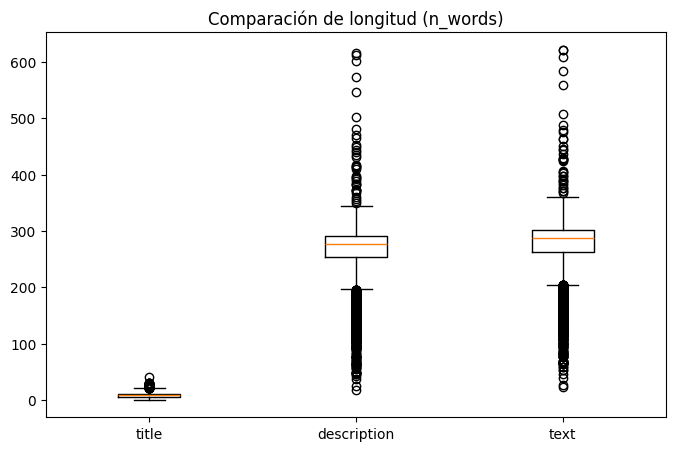

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(
    [df["title_n_words"], df["description_n_words"], df["text_n_words"]],
    labels=["title", "description", "text"]
)
plt.title("Comparación de longitud (n_words)")
plt.show()


Del boxplot, podemos observar:
* title es claramente distinto en escala (muy corto). Los bigotes son muy cortos porque la variabilidad es baja.
* description y text tienen distribuciones similares, aunque text parece ligeramente más largo.
* Hay una cola larga hacia arriba en description y text → existen documentos muy extensos.
* La presencia de muchos puntos fuera de los bigotes (muestran el rango típico de los datos) indica alta variabilidad y posibles outliers importantes.

En resumen, el corpus tiene:
* Alta homogeneidad estructural
* Longitudes muy similares entre proyectos
* Algunos outliers largos que conviene revisar
* Muy baja varianza en títulos

Esto sugiere:
* Formato institucional fuerte.
* Posible boilerplate repetido.
* Dominio consistente.

Nos conviene estudiar la *similitud proyecto–proyecto* porque podría estar inflada por estructura común.

El valor discriminativo real puede estar en términos técnicos específicos, el título, ciertas secciones del abstract.

Antes de clasificar contra PAE, tiene mucho sentido:

* Medir similitud proyecto–proyecto.
* Detectar boilerplate (texto estándar que se repite en los proyectos) repetido.
* Evaluar si truncar a primeras 200 palabras mejora separación.

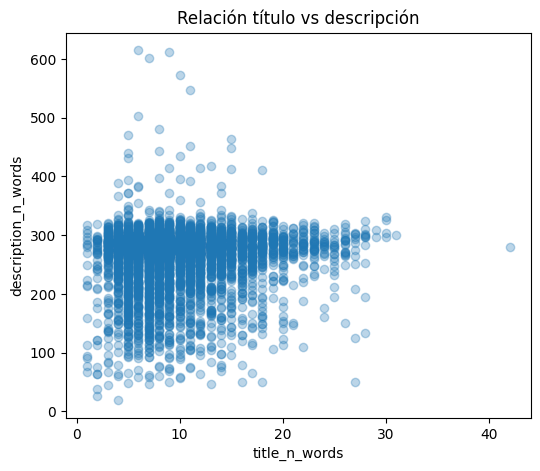

In [35]:
plt.figure(figsize=(6,5))
plt.scatter(df["title_n_words"], df["description_n_words"], alpha=0.3)
plt.xlabel("title_n_words")
plt.ylabel("description_n_words")
plt.title("Relación título vs descripción")
plt.show()

La nube es horizontal, no diagonal. Esto ya nos dice algo importante:
no hay correlación clara entre longitud del título y longitud de la descripción.

Si hubiese relación estructural fuerte veríamos una tendencia ascendente clara (más largo el título → más larga la descripción).

Pero estamos viendo que la dispersión vertical es muy grande para cualquier longitud de título. Proyectos con 6 palabras en el título pueden tener 100 o 400 palabras en la descripción.

Esto sugiere:

* El título y la descripción son independientes estructuralmente.
* La descripción sigue probablemente un formato institucional fijo.
* El título no determina el tamaño del abstract.


Este gráfico sugiere algo importante: **el título podría aportar información complementaria y no redundante respecto a la descripción**.
Si hubiera correlación fuerte, significaría que el título es simplemente un resumen proporcional del abstract. Pero no la hay. Por tanto, *el título puede aportar señal discriminativa adicional*.


Por tanto:
* Debemos usar title + description sin riesgo de colinealidad estructural.
* El título no introduce sesgo de longitud.
* La variabilidad semántica real vendrá del contenido, no del tamaño.

## Densidad lexica

Medimos el número de tokens únicos entre el número total de tokens.

Una densidad léxica cercana a 1.0 implica que en el texto casí no hay tokens repetidos.



In [45]:
import re
def lexical_density(text):
    words = re.findall(r"[A-Za-z]+", str(text).lower())
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

df["title_lex_density"] = df["title"].apply(lexical_density)
df["desc_lex_density"] = df["description"].apply(lexical_density)

df[["title_lex_density", "desc_lex_density"]].describe()

,title_lex_density,desc_lex_density
count,5374.000000,5374.000000
mean,0.979856,0.582785
std,0.045238,0.052208
min,0.571429,0.382759
25%,1.000000,0.549153
50%,1.000000,0.581818
75%,1.000000,0.613559
max,1.000000,0.947368


Como era de esperar, el título (cuya media es 0.97) es muy informativo y con mínima redundancia (casí no tiene palabras repetidas). Por tanto, podría aportar mucha información semántica.


También como era esperable, en el campo description su media es más baja (0.58), lo que significa que aproximadamente el 42% de los tokens son repeticiones. Esto es completamente normal en textos largos (~270 palabras).

Pero hay algo interesante, y es que su desviación es muy baja (0.05), es decir, la mayoría de los proyectos tienen densidad léxica muy similar. Por tanto, podemos inferir que la redacción es homogénea, y que probablemente comparten estructura narrativa común. Esto es típico de abstracts institucionales y plantillas de convocatorias EU.

En resumen:
* El título es altamente informativo y no redundante.
* La descripción introduce repetición estructural.

El siguiente histograma muestra la distribución del número de tokens únicos por descripción. Podemos ver:
* Distribución claramente unimodal.
* Pico alrededor de 150–170 tokens únicos.
* Cola derecha ligera (algunos documentos con 200–280 tokens únicos).
* Muy pocos valores extremadamente bajos (<50).


Eso significa:

* La variabilidad léxica entre proyectos es limitada.
* No hay subgrupos extremadamente distintos en vocabulario bruto.
* El dominio está bien acotado.

Por tanto, el corpus es estructuralmente muy homogéneo también en riqueza léxica.

Sabemos que la longitud media de los textos es 264 palabras.
Tokens únicos ≈ 150–170.

Eso implica una tasa de repetición razonable: 55%, que coincide con la densidad léxica (0.58) que hemos calculado antes.


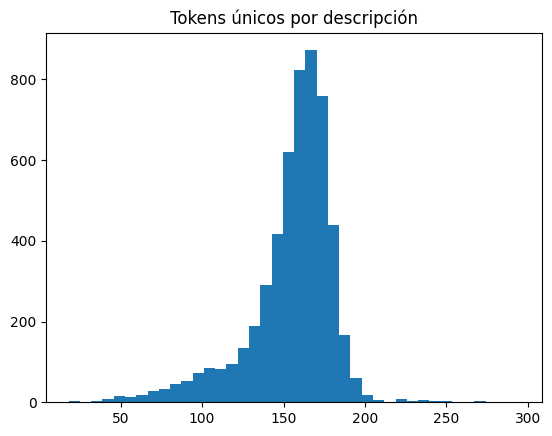

In [44]:
df["desc_unique_tokens"] = df["description"].apply(
    lambda x: len(set(re.findall(r"[A-Za-z]+", str(x).lower())))
)

plt.hist(df["desc_unique_tokens"], bins=40)
plt.title("Tokens únicos por descripción")
plt.show()

### Inspección de outliers

Top 5 más largos

In [39]:
df.sort_values("description_n_words", ascending=False)[
    ["title", "description_n_words"]
].head(5)

,title,description_n_words
2794,Improving Models for Marine EnviRonment SErvices,615
5123,CITIES 4.0 - Climate Innovation Through Intera...,611
3994,Open ScienCe Aeronautic & Air Transport Research,601
1401,Design Study of a European Facility for Advanc...,573
1471,Power Optimised Ship for Environment with Elec...,547


In [40]:
df.sort_values("description_n_words")[["title", "description_n_words"]].head(5)


,title,description_n_words
4278,Green Turbine WHR System,19
3999,Fast Rotorcraft,26
3534,Systems ITD,38
3513,Large Passenger Aircraft,44
2237,Full scale innovative composite windows frames...,46


Ahora sí tiene mucho sentido hacer:

👉 Similitud proyecto–proyecto

Porque estructuralmente el corpus es homogéneo, pero necesitamos saber si:

También lo es semánticamente.

O hay clusters naturales aeroespaciales.

## Conclusión:

Tu corpus no parece:

- Ruido.
- Mezcla de dominios distintos.
- Extremadamente diverso.
- Parece un corpus técnico homogéneo con variación temática interna.

Eso es ideal para clasificación con embeddings.